<a href="https://colab.research.google.com/github/Aggarwalmansi/GENAI/blob/main/Lecture_18_MultivariateAnalysis_Skeleton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 18: Multivariate Analysis

**Dataset:** Walmart.csv : https://drive.google.com/file/d/16Xij2C8nitiw1LsS7ZJQSYK78uSMQkYV/view?usp=sharing

**Focus:** Analyzing relationships involving three or more variables using visualization and aggregation

## Before We Begin

In this lecture, we move beyond two-variable analysis.

We will focus on:
- Visualizing **three or more variables together**
- Understanding **time-based aggregation**
- Summarizing complex relationships using **pivot tables and heatmaps**

This lecture emphasizes **interpretation**, not just plotting.

## Ensure the Walmart dataset is loaded and required libraries are available.

We begin by loading the dataset and required libraries.
Our focus is on analysis and interpretation, not data cleaning.

In [ ]:
# Import core libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Improve display readability
pd.set_option('display.max_columns', 50)

> Always inspect the dataset before analysis to understand available columns and data types.

In [ ]:
# Load the Walmart dataset
# Ensure the file path is correct before proceeding
df = pd.read_csv('Walmart.csv')
df.head()

,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,13-06-2013,17-06-2013,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,6.87
1,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7.0,14.17
2,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.28,4.0,1.97
3,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.15,4.0,90.72
4,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3.0,5.78


## 1. Introduction

What if we want to understand:
- When a product sells the most
- Whether it is profitable
- And how this differs across categories?

This requires **multiple variables**, not just two.

## 2.1 Encoding Variables

### 2.1.1 Adding a Third Dimension (Hue)

We start by visualizing:
- Sales (x-axis)
- Profit (y-axis)
- Category (color / hue)

Each point now represents **three variables simultaneously**.

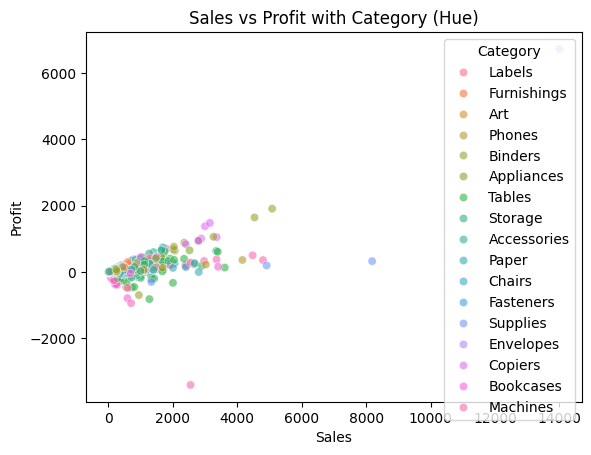

In [ ]:
# Visualizing Sales vs Profit
# Category is encoded using color (hue)
sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    hue='Category',
    alpha=0.6
)
plt.title('Sales vs Profit with Category (Hue)')
plt.show()

> Hue allows us to introduce a third variable without changing axes.


### 2.1.2 Adding a Fourth Dimension (Size)

We now encode Quantity using point size.
This introduces a **fourth variable**.

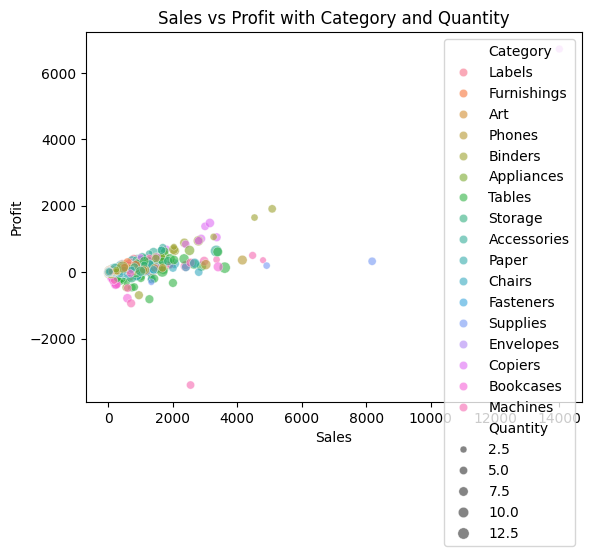

In [ ]:
sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    hue='Category',
    size='Quantity',
    alpha=0.6
)
plt.title('Sales vs Profit with Category and Quantity')
plt.show()

> Encoding too many variables can reduce clarity. Always ask what insight you’re trying to surface.

### Checkpoint 1

Create a scatter plot of:
- Quantity vs Profit
- Colored by State

What limitation do you notice when too many variables are encoded?

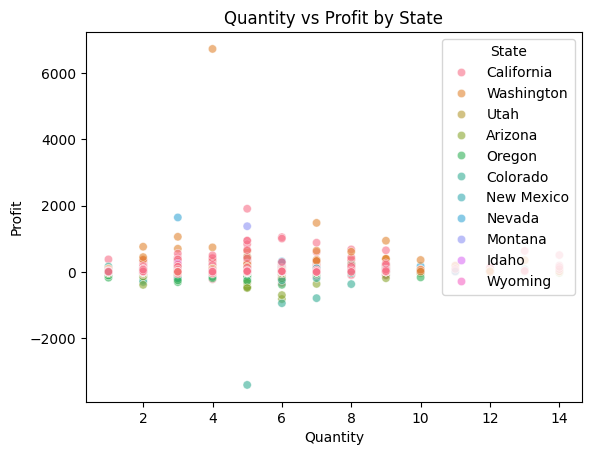

In [ ]:
## todo

> This plot intentionally becomes cluttered — that’s part of the lesson.

## 2.2 Time Series Analysis

### 2.2.1 Date Conversion & Aggregation

Before time-based analysis, dates must be converted to datetime.

In [ ]:
# Convert Order Date to datetime
# Dates are in DD-MM-YYYY format, so we explicitly set dayfirst=True

df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True,
    errors='coerce'
)

> Never rely on Pandas’ default date guessing in analytical work. Always be explicit.

In [ ]:
# Grouping by monthly periods allows us to analyze trends over time
# Aggregate total monthly sales
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()
monthly_sales.head()

,Sales
Order Date,
2011-01,2648.05
2011-02,1348.64
2011-03,11008.91
2011-04,9343.49
2011-05,6570.44


### 2.2.2 Time Series Line Chart

We visualize how Sales evolve over time.

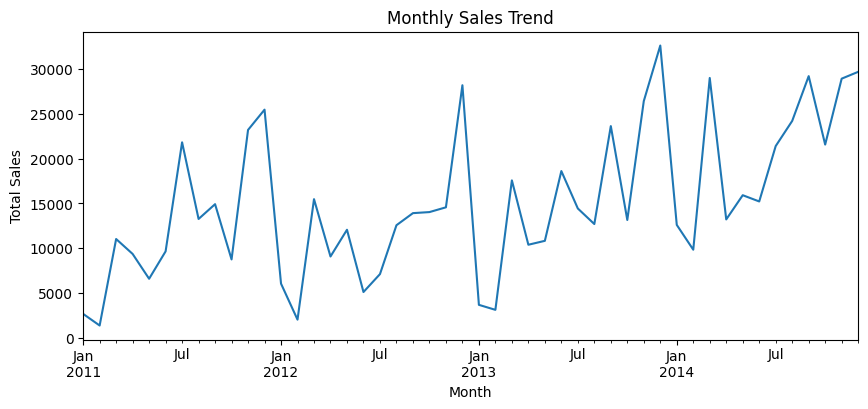

In [ ]:
# Visualize monthly sales trend
monthly_sales.plot(figsize=(10,4))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

> Trends over time often reveal patterns not visible in raw transaction data.

### Checkpoint 2

Write the code to extract the **Year** from the Order Date column.

In [ ]:
## todo

In [ ]:
df[['Order Date', 'Order Year']].head()

,Order Date,Order Year
0,2013-06-13,2013
1,2011-06-09,2011
2,2011-06-09,2011
3,2011-06-09,2011
4,2011-06-09,2011


## 2.3 Complex Aggregation & Heatmaps

### 2.3.1 Pivot Tables

We now summarize Profit across:
- Category
- State

In [ ]:
# Create a pivot table summarizing average Profit
# Rows represent Category, columns represent State
pivot_profit = pd.pivot_table(
    df,
    values='Profit',
    index='Category',
    columns='State',
    aggfunc='mean'
)
# pivot_profit.head()
pivot_profit.round(2).head()

State,Arizona,California,Colorado,Idaho,Montana,Nevada,New Mexico,Oregon,Utah,Washington,Wyoming
Category,,,,,,,,,,,
Accessories,10.22,75.48,14.97,37.79,91.32,44.72,52.87,15.21,20.66,80.44,NaN
Appliances,13.88,74.39,15.71,66.07,NaN,13.60,NaN,9.02,305.13,34.82,NaN
Art,10.07,9.79,2.28,NaN,NaN,14.90,29.83,4.66,7.22,9.42,NaN
Binders,-47.05,36.24,-13.55,4.93,52.47,252.63,9.02,-14.20,21.86,70.49,NaN
Bookcases,-289.74,27.29,-267.66,NaN,NaN,41.17,NaN,-205.61,109.14,57.00,NaN


Notice that some Category–State combinations have no data,
which results in missing values (`NaN`) in the pivot table.

> Pivot tables convert long-form data into structured matrices for pattern discovery.

### 2.3.2 Heatmap Visualization

Heatmaps help us **instantly spot patterns** in complex aggregations.

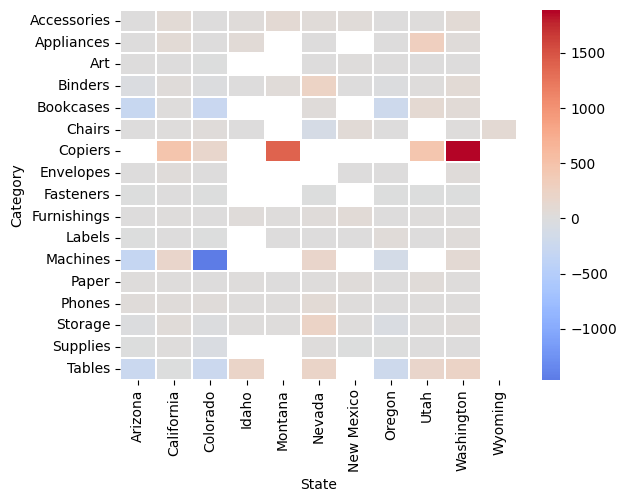

<Figure size 640x480 with 0 Axes>

In [ ]:
# Visualize the pivot table using a heatmap
sns.heatmap(
    pivot_profit,
    cmap='coolwarm',
    center=0,
    linewidths=0.3
)
plt.show()
plt.tight_layout()

### Heatmap Color Description

*   Red = high profit
*   Blue = loss
*   White = Neutral

***Look for patterns across rows (category) and columns (state)***



> Heatmaps make relative differences immediately visible across multiple dimensions.

### Checkpoint 3

Create a pivot table showing **Total Quantity**:
- Indexed by State
- Grouped by Category

How does a heatmap help compared to reading the raw table?

In [ ]:
## todo

Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
State,,,,,,,,,,,,,,,,,
Arizona,85.0,21.0,47.0,155.0,18.0,52.0,NaN,28.0,23.0,82.0,9.0,9.0,124.0,79.0,78.0,16.0,36.0
California,568.0,346.0,644.0,1057.0,198.0,466.0,60.0,149.0,148.0,751.0,349.0,86.0,1091.0,689.0,637.0,145.0,281.0
Colorado,76.0,38.0,32.0,112.0,41.0,53.0,1.0,16.0,12.0,92.0,5.0,13.0,64.0,59.0,51.0,14.0,14.0
Idaho,3.0,4.0,NaN,12.0,NaN,3.0,NaN,NaN,NaN,10.0,NaN,NaN,13.0,9.0,5.0,NaN,5.0
Montana,6.0,NaN,NaN,6.0,NaN,NaN,5.0,NaN,NaN,7.0,2.0,NaN,5.0,7.0,18.0,NaN,NaN
Nevada,5.0,9.0,16.0,32.0,2.0,3.0,NaN,NaN,1.0,22.0,3.0,10.0,27.0,18.0,5.0,5.0,10.0
New Mexico,23.0,NaN,17.0,16.0,NaN,7.0,NaN,5.0,NaN,12.0,5.0,NaN,28.0,18.0,17.0,3.0,NaN
Oregon,49.0,17.0,51.0,70.0,9.0,27.0,NaN,10.0,8.0,15.0,36.0,8.0,79.0,50.0,32.0,20.0,18.0
Utah,19.0,3.0,10.0,43.0,10.0,NaN,5.0,NaN,7.0,11.0,10.0,NaN,53.0,21.0,14.0,5.0,8.0


> Always confirm what your aggregation represents — totals vs averages matter.

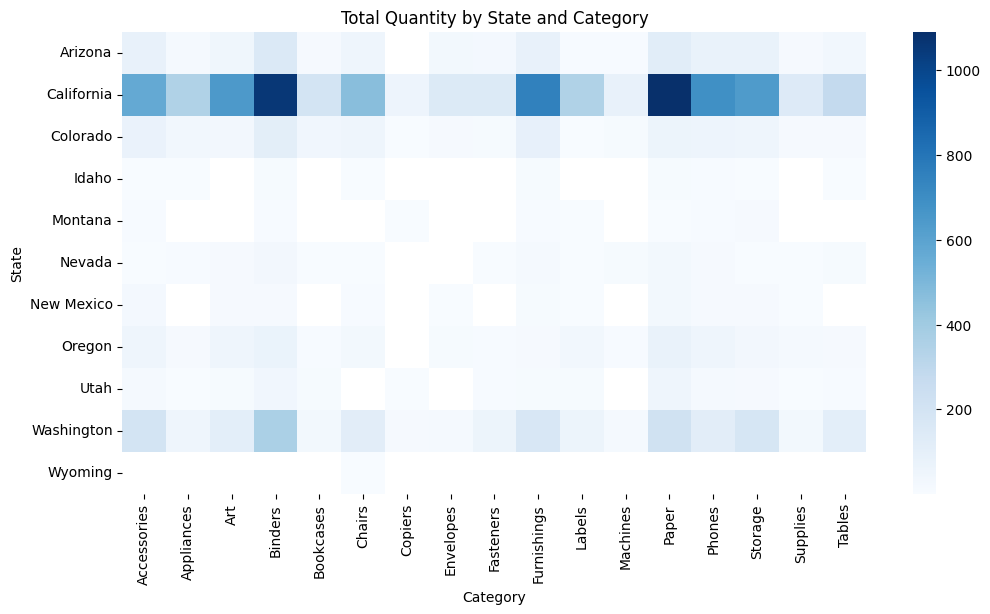

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_quantity, cmap='Blues')
plt.title('Total Quantity by State and Category')
plt.show()

plt.tight_layout()


> Points to consider:
> - Encoding too many categories using color can reduce clarity.
> - This activity highlights the trade-off between information richness and readability.
> - In practice, you may need to filter or facet data before plotting.


## Student Activities & Exercises

### Activity 1: Multivariate Scatter Plot

Create a scatter plot to analyze the relationship between:
- Sales (x-axis)
- Profit (y-axis)

Additionally:
- Use **Category** as color (hue)
- Use **Quantity** as size

Observe:
- Which categories show higher profit margins?
- Does higher quantity always imply higher profit?

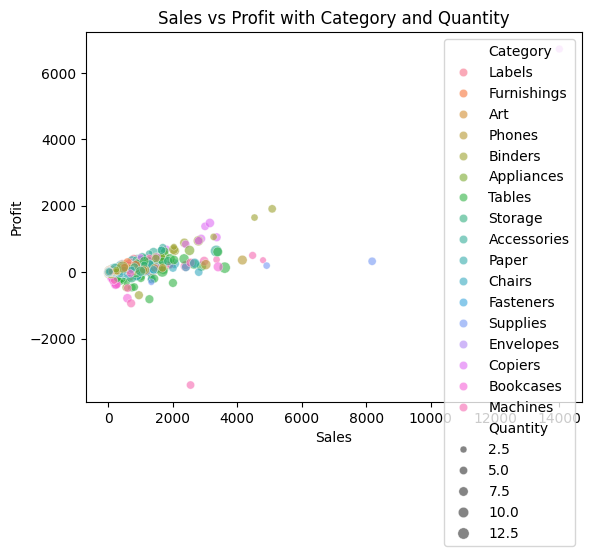

<Figure size 640x480 with 0 Axes>

In [ ]:
## todo

### Activity 2: Monthly Sales Trend

Using the Order Date column:
1. Aggregate total Sales by month
2. Plot a line chart of monthly Sales

Questions to think about:
- Do you observe any seasonality?
- Are there consistent growth or decline periods?

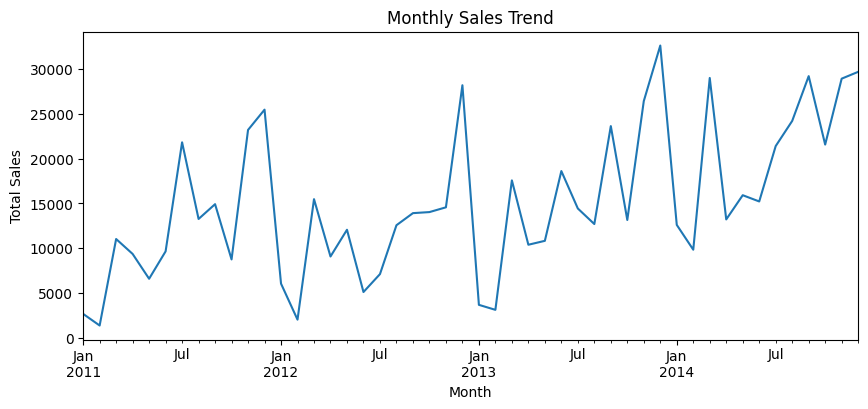

In [ ]:
## todo

## Post-Class Exercises

### Exercise 1: Profit Analysis by Category and State

Create a pivot table showing:
- Average Profit
- Grouped by Category and State

Then visualize the result using a heatmap.

Which Category–State combinations appear most profitable?

State        Arizona  California  Colorado   Idaho  Montana  Nevada  \
Category                                                              
Accessories    10.22       75.48     14.97   37.79    91.32   44.72   
Appliances     13.88       74.39     15.71   66.07      NaN   13.60   
Art            10.07        9.79      2.28     NaN      NaN   14.90   
Binders       -47.05       36.24    -13.55    4.93    52.47  252.63   
Bookcases    -289.74       27.29   -267.66     NaN      NaN   41.17   
Chairs          7.60       18.74     39.75    4.23      NaN -109.58   
Copiers          NaN      464.11    165.00     NaN  1379.98     NaN   
Envelopes      10.74       33.25      5.41     NaN      NaN     NaN   
Fasteners       0.35        4.66      3.16     NaN      NaN    0.00   
Furnishings    13.55       29.38      6.00   36.68    21.75   31.16   
Labels          3.04       16.51      3.00     NaN     6.87    6.87   
Machines     -310.32      181.54  -1461.42     NaN      NaN  179.73   
Paper 

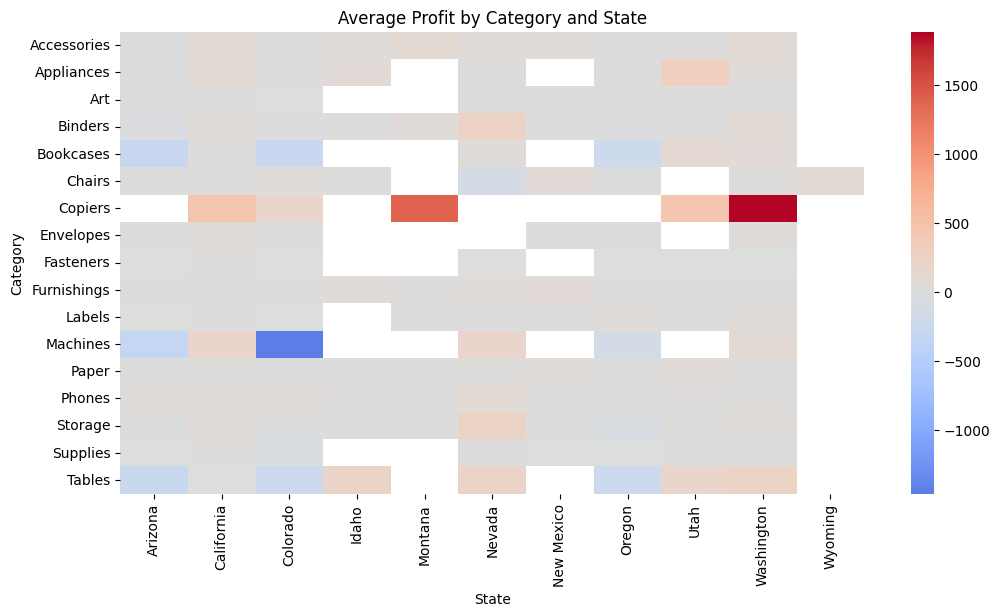

In [ ]:
## todo

### Exercise 2: Quantity Trend Over Time

Aggregate total Quantity by year and plot the trend.

Questions:
- Is Quantity increasing over time?
- Does Quantity trend align with Sales trend?

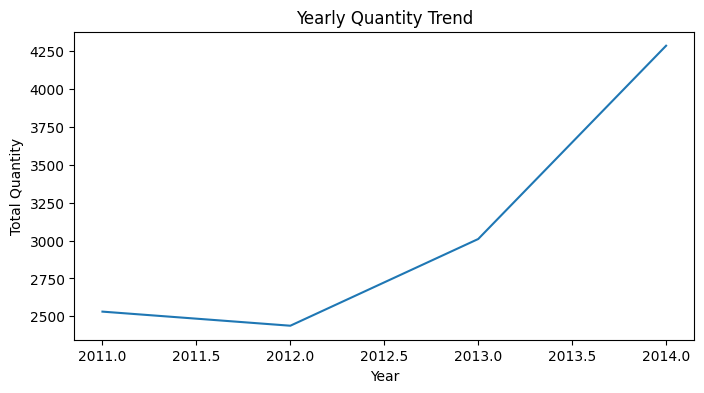

In [ ]:
## todo

### Exercise 3: High-Impact Categories Over Time (Advanced)

For each Category:

1. Aggregate total Sales and total Profit by Year
2. Calculate the Profit Margin:
   Profit Margin = Total Profit / Total Sales
3. Identify the Category that has:
   - The highest average Profit Margin across all years
4. Visualize the Profit Margin trend of that Category over time

Questions to answer:
- Which Category is the most consistently profitable?
- Does high Sales always imply high Profit Margin?

In [ ]:
# Step 1. Aggregate Sales & Profit by Year & Category
## todo

In [ ]:
# Step 2: Compute Profit

# todo

In [ ]:
# Step 3: Find Category with Highest Average Profit Margin
# todo

'Envelopes'

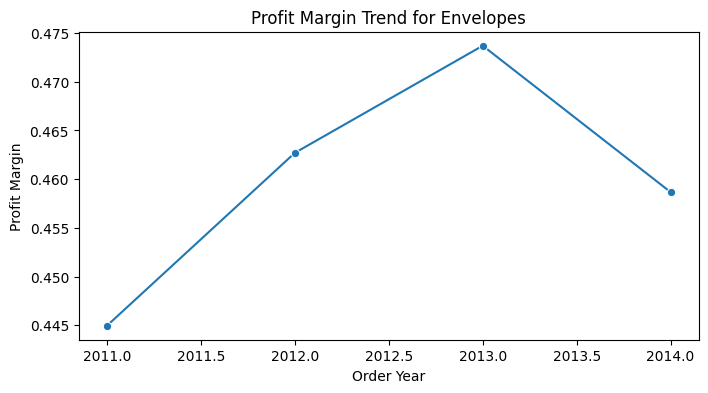

In [ ]:
# Step 4: Visualize Profit Margin Trend for That Category
# todo

> High sales do not always imply high profitability — margins matter.

## Summary

In this lecture, we learned how to:
- Encode multiple variables into a single visualization
- Perform time-based aggregation for trend analysis
- Use pivot tables and heatmaps to uncover complex patterns

Multivariate analysis enables richer insights by combining
**visual reasoning with structured aggregation**.